# Computing P-values and Confidence Intervals

## 📚 Learning Objectives

By completing this notebook, you will:
- Compute p-values for hypothesis tests
- Calculate confidence intervals for population parameters
- Interpret p-values and confidence intervals
- Understand the relationship between p-values and confidence intervals

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 01 "Regression vs Classification" — a single accuracy number with nothing around it; here you learn to attach an interval.

**Used later in:** Course 04 (AIAT 114) — Unit 2 — reporting cross-validation scores with their spread instead of one figure.

---

This notebook covers practical activities from **Course 03, Unit 5**:
- Computing p-values and confidence intervals

---

## Introduction

**P-values** measure evidence against the null hypothesis, and **confidence intervals** provide a range of plausible values for population parameters.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Setup: NumPy, Matplotlib, scipy.stats for the t-tests and interval formulas,
# and pandas to load the real Titanic records.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path


def data_path(filename):
    """Locate a shared raw dataset by walking up from this notebook's folder.

    All courses share one datasets folder, so we search upward for it instead of
    hard-coding a fragile relative path.
    """
    for base in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        candidate = base / "Course 04" / "datasets" / "raw" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"{filename} not found under any Course 04/datasets/raw")


# Confirm the environment is ready before any math starts.
print("✅ Libraries imported!")
print("\nComputing P-values and Confidence Intervals")
print("=" * 60)


✅ Libraries imported!

Computing P-values and Confidence Intervals


## Part 1: Computing P-values


In [2]:
# Compute p-values for three hypothesized means against the same REAL sample.
# Watch the p-value collapse as H0 drifts from what the data says - that is evidence accumulating.

print("=" * 60)
print("Part 1: Computing P-values")
print("=" * 60)

# Real population: the 714 Titanic passengers whose age was recorded. We happen to hold
# ALL of them, so we know the population mean exactly - which lets us check later whether
# our interval actually caught it. Then we draw one random sample of 100, the way a real
# survey would, and do inference from that sample alone.
titanic = pd.read_csv(data_path("titanic.csv"))
population = titanic["Age"].dropna().to_numpy()
true_mean = population.mean()          # a genuine population parameter, not an invented one

rng = np.random.default_rng(42)        # sampling is simulated on purpose; the ages are real
sample = rng.choice(population, size=100, replace=False)
sample_mean = np.mean(sample)
sample_std = np.std(sample, ddof=1)

print(f"\nPopulation: {len(population)} recorded Titanic passenger ages")
print(f"Population mean age: {true_mean:.4f} years")
print(f"\nSample drawn from it: n = {len(sample)}")
print(f"Sample mean: {sample_mean:.4f}")
print(f"Sample std:  {sample_std:.4f}")

# P-value: probability of observing data this extreme IF H0 is true
# One-sample t-test: H0: mu = hypothesized value
for h0 in [30, 33, 36]:
    t_stat, p_value = stats.ttest_1samp(sample, h0)
    decision = "Reject H0 (p < 0.05)" if p_value < 0.05 else "Fail to reject H0 (p >= 0.05)"
    print(f"\nTest - H0: mu = {h0}")
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value:     {p_value:.4f}")
    print(f"  Decision:    {decision}")

print("\nInterpretation: A small p-value means the observed sample would be")
print("very unlikely if H0 were true - evidence AGAINST H0.")

print("\n✅ P-values computed on a real sample!")


Part 1: Computing P-values

Population: 714 recorded Titanic passenger ages
Population mean age: 29.6991 years

Sample drawn from it: n = 100
Sample mean: 29.8025
Sample std:  14.7211

Test - H0: mu = 30
  t-statistic: -0.1342
  p-value:     0.8935
  Decision:    Fail to reject H0 (p >= 0.05)

Test - H0: mu = 33
  t-statistic: -2.1720
  p-value:     0.0322
  Decision:    Reject H0 (p < 0.05)

Test - H0: mu = 36
  t-statistic: -4.2099
  p-value:     0.0001
  Decision:    Reject H0 (p < 0.05)

Interpretation: A small p-value means the observed sample would be
very unlikely if H0 were true - evidence AGAINST H0.

✅ P-values computed on a real sample!


## Part 2: Computing Confidence Intervals


In [3]:
# Build confidence intervals for the mean and see how the confidence level sets the width.
# More confidence costs a wider interval — certainty is never free.

print("\n" + "=" * 60)
print("Part 2: Computing Confidence Intervals")
print("=" * 60)

# 95% confidence interval for the mean (t-distribution)
sem = stats.sem(sample)  # Standard error of the mean
ci_lower, ci_upper = stats.t.interval(0.95, df=len(sample) - 1,
                                      loc=sample_mean, scale=sem)

print(f"\nSample mean:     {sample_mean:.4f}")
print(f"Standard error:  {sem:.4f}")
print(f"95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
in_ci = ci_lower <= true_mean <= ci_upper
print(f"Contains the true population mean ({true_mean:.2f})? {'Yes' if in_ci else 'No'}")
print("We can check this only because we happen to hold the whole population. In a real")
print("study you never can - which is exactly why the interval is stated with a confidence level.")

# Effect of confidence level: higher confidence -> wider interval
print("\nEffect of confidence level:")
for conf in [0.90, 0.95, 0.99]:
    lo, hi = stats.t.interval(conf, df=len(sample) - 1, loc=sample_mean, scale=sem)
    print(f"  {conf:.0%} CI: [{lo:.4f}, {hi:.4f}]  (width: {hi - lo:.4f})")

print("\nInterpretation: If we repeated this experiment many times,")
print("95% of the intervals built this way would contain the true mean.")

print("\n\u2705 Confidence intervals computed!")



Part 2: Computing Confidence Intervals

Sample mean:     29.8025
Standard error:  1.4721
95% CI: [26.8815, 32.7235]
Contains the true population mean (29.70)? Yes
We can check this only because we happen to hold the whole population. In a real
study you never can - which is exactly why the interval is stated with a confidence level.

Effect of confidence level:
  90% CI: [27.3582, 32.2468]  (width: 4.8886)
  95% CI: [26.8815, 32.7235]  (width: 5.8420)
  99% CI: [25.9361, 33.6689]  (width: 7.7327)

Interpretation: If we repeated this experiment many times,
95% of the intervals built this way would contain the true mean.

✅ Confidence intervals computed!


## Part 3: Relationship Between P-values and Confidence Intervals



Part 3: Relationship Between P-values and Confidence Intervals

Key Relationship:
  If 95% CI excludes the hypothesized value, then p < 0.05
  If 95% CI includes the hypothesized value, then p ≥ 0.05

Testing different hypothesized means:
  95% CI: [26.8815, 32.7235]

Hypothesized Value | In CI? | p-value | Reject H0?
    24.0         | No    | 0.0002 | Yes     
    27.0         | Yes   | 0.0599 | No      
    30.0         | Yes   | 0.8935 | No      
    33.0         | No    | 0.0322 | Yes     
    36.0         | No    | 0.0001 | Yes     


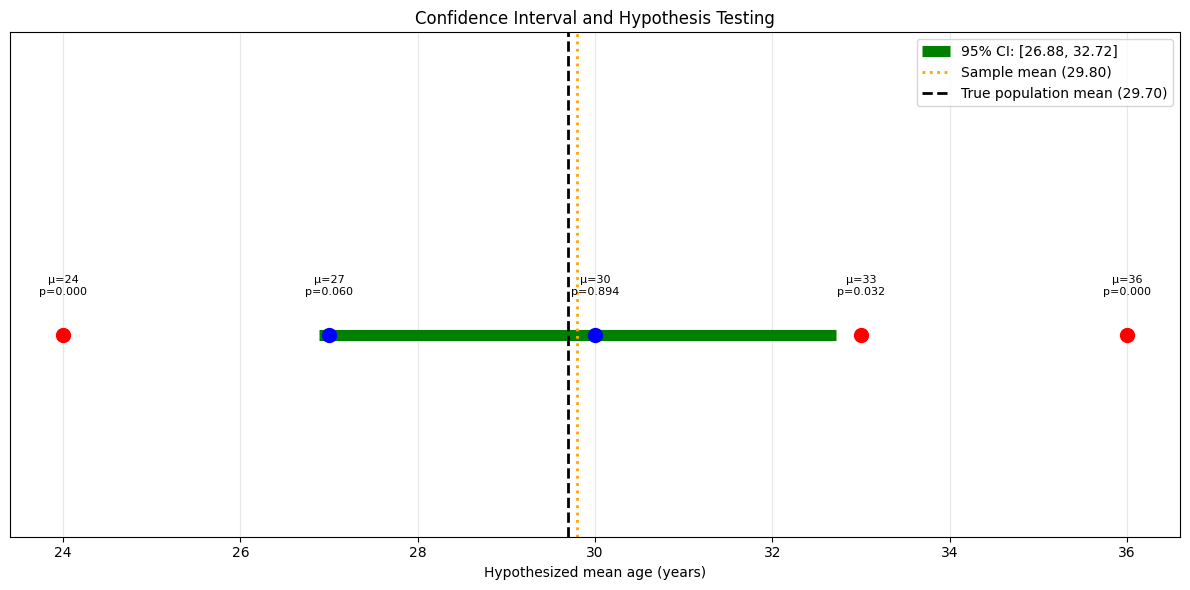


Every row obeys the same rule: 'in the interval' and 'not rejected' always agree.
The 95% CI is exactly the set of hypotheses this sample cannot reject at α = 0.05.

✅ Relationship between p-values and confidence intervals demonstrated!


In [4]:
# The duality: a value inside the 95% CI cannot be rejected at α = 0.05, one outside can.
# The table and figure below make the CI–p-value correspondence explicit.

print("\n" + "=" * 60)
print("Part 3: Relationship Between P-values and Confidence Intervals")
print("=" * 60)

# Relationship: If 95% CI excludes H0 value, p < 0.05
print("\nKey Relationship:")
print("  If 95% CI excludes the hypothesized value, then p < 0.05")
print("  If 95% CI includes the hypothesized value, then p ≥ 0.05")

# Demonstrate with different hypothesized values
hypothesized_values = [24, 27, 30, 33, 36]

print(f"\nTesting different hypothesized means:")
print(f"  95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"\nHypothesized Value | In CI? | p-value | Reject H0?")

for h0_val in hypothesized_values:
    t_stat, p_val = stats.ttest_1samp(sample, h0_val)
    in_ci = ci_lower <= h0_val <= ci_upper
    reject = p_val < 0.05
    print(f"  {h0_val:6.1f}         | {'Yes' if in_ci else 'No':5} | {p_val:.4f} | {'Yes' if reject else 'No':8}")

# Visualize
plt.figure(figsize=(12, 6))
plt.hlines(0, ci_lower, ci_upper, colors='green', linewidth=8, label=f'95% CI: [{ci_lower:.2f}, {ci_upper:.2f}]')
for h0_val in hypothesized_values:
    t_stat, p_val = stats.ttest_1samp(sample, h0_val)
    color = 'red' if p_val < 0.05 else 'blue'
    plt.plot(h0_val, 0, 'o', color=color, markersize=10)
    plt.text(h0_val, 0.02, f'μ={h0_val}\np={p_val:.3f}', ha='center', fontsize=8)
plt.axvline(sample_mean, color='orange', linestyle=':', linewidth=2, label=f'Sample mean ({sample_mean:.2f})')
plt.axvline(true_mean, color='black', linestyle='--', linewidth=2, label=f'True population mean ({true_mean:.2f})')
plt.xlabel('Hypothesized mean age (years)')
plt.ylabel('')
plt.title('Confidence Interval and Hypothesis Testing')
plt.legend()
plt.grid(True, alpha=0.3, axis='x')
plt.ylim(-0.1, 0.15)
plt.yticks([])
plt.tight_layout()
plt.show()

print("\nEvery row obeys the same rule: 'in the interval' and 'not rejected' always agree.")
print("The 95% CI is exactly the set of hypotheses this sample cannot reject at α = 0.05.")

print("\n✅ Relationship between p-values and confidence intervals demonstrated!")

## Summary

### Key Concepts:
1. **P-value**: Probability of observing data (or more extreme) if H0 is true
2. **Confidence Interval**: Range of plausible values for parameter
3. **Relationship**: 95% CI excludes H0 value ↔ p < 0.05
4. **Interpretation**: 
   - P-value: Evidence against H0 (lower = stronger evidence)
   - CI: Range of parameter values consistent with data

### Best Practices:
- Report both p-values and confidence intervals
- Don't interpret p-value as probability H0 is true
- Consider effect size, not just significance
- Use appropriate confidence level (usually 95%)

### Applications:
- Statistical inference
- Scientific reporting
- Decision making
- Quality control

**Reference:** Course 03, Unit 5: "Probability and Statistical Inference" - P-values and confidence intervals practical content

## 📚 References

1. Neyman, J. (1937). *Outline of a Theory of Statistical Estimation Based on the Classical Theory of Probability*. Philosophical Transactions of the Royal Society A, 236, 333–380.
2. Wasserstein, R. L., & Lazar, N. A. (2016). *The ASA Statement on p-Values: Context, Process, and Purpose*. The American Statistician, 70(2), 129–133. <https://doi.org/10.1080/00031305.2016.1154108>
3. Greenland, S., Senn, S. J., Rothman, K. J., Carlin, J. B., Poole, C., Goodman, S. N., & Altman, D. G. (2016). *Statistical Tests, P Values, Confidence Intervals, and Power: A Guide to Misinterpretations*. European Journal of Epidemiology, 31, 337–350. <https://doi.org/10.1007/s10654-016-0149-3>